In [1]:
import numpy as np
from scipy.special import comb
from scipy.integrate import *
from scipy.linalg import pinv, pinvh, expm

from opt_einsum import contract, contract_expression

import matplotlib.pyplot as plt

from electron_integrals import *
from SemiDirectCI import SemiDirectCI

from CI_physicist import *


Define functions

In [12]:
# Helper functions to put the problem on a form handled by standard SciPy ODE solvers 
def Cb_to_y(C, b):
    return np.concatenate([C.flatten(), b.flatten()])

def y_to_Cb(y, num_mctdhf_orbitals, num_spin_orbitals, num_slater_dets):

    C, b = np.split(y, [num_slater_dets])
    b = b.reshape((num_spin_orbitals, num_mctdhf_orbitals))

    return C, b

def gram_schmidt(b):
    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))
    for i in range(b.shape[1]):

        orto_adjustment = 0
        for j in range(0, i):
            orto_adjustment += np.dot(b[:, i], b[:, j])*b[:, j]

        b[:,i] -= orto_adjustment

    return b

def overlap_ortnorm(b):
    b = np.divide(b, np.sqrt(contract('ij, ij -> j', b.conj(), b)))
    u, _, vh = np.linalg.svd(b, full_matrices=False)
    return u@vh

def normalize_C(C):
    return np.divide(C, np.sqrt(C.T.conj()@C))

def get_E(dCI, h, g, b, C, C_shape):
    bc = b.conj()
    h_1 = contract('jm, ij -> im', b, h)
    h_2 = contract('in, im -> nm', bc, h_1)

    g_2 = contract('jq, ls, ijkl -> iqks', bc, b, g)
    g_3 = contract('kr, iqks -> iqrs', b, g_2)
    g_4 = contract('ip, iqrs -> pqrs', bc, g_3)

    return dCI.calculate_energy(np.reshape(C, C_shape), h_2, g_4)

Define number of electrons and orbitals

In [4]:
# Number of spatial orbitals
num_spatial_orbitals = 10
# Number of electrons
num_alpha_electrons = 1
num_beta_electrons = 1

Calculate electron integrals

In [5]:
x_max = 10
num_points = 1000
x = np.linspace(-x_max,x_max,num_points)

#x = np.arange(-10,10.1,0.1)

#pot = GaussianWell(w=100, a=1, center=0)
#pot = HOPotential(0.25/np.sqrt(2)) # Zhangellini
pot = HOPotential()

spf, h = get_spf_and_diag_h(num_spatial_orbitals, x, pot)

g = coulomb_interaction_matrix_elements(spf, spf, x, x, kappa = 1, a = 0.01) # 0.25 in Zhangellini

# Sanity test, due to symmetry in g this should be zero:
np.testing.assert_almost_equal(0, -g[2,1,1,0]+g[2,0,1,1]+g[1,1,2,0]-g[1,0,2,1])

# Orbital equations

Define number of MCTDHF orbitals $(\{\ket{\phi_n(t)}\})$, initial b's (basis reduction coefficients),

$\ket{\phi_n(t)} = \sum_{k=1}^{N_b}b_{kn}(t)\ket{\psi_k}$,

and initial C's.


In [6]:
num_mctdhf_orbitals = 6
num_mctdhf_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
num_mctdhf_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
num_mctdhf_dets = num_mctdhf_alpha_dets*num_mctdhf_beta_dets
C_shape = (num_mctdhf_alpha_dets, num_mctdhf_beta_dets)


# Distributed vales
#b_init = np.zeros((num_spin_orbitals, num_mctdhf_orbitals))
#a = int(num_spin_orbitals/num_mctdhf_orbitals)
#for i in range(num_mctdhf_orbitals):
#    b_init[a*i:a*(i+1), i] = np.ones(a)

# Identity
#b_init=np.eye(num_spin_orbitals, num_mctdhf_orbitals)

# Generate random orthonormal vectors
rng = np.random.default_rng()
r = rng.random((num_spatial_orbitals, num_mctdhf_orbitals))
u, _, vh = np.linalg.svd(r, full_matrices=False)
b_init = (u@vh).astype(np.cdouble)

#print(b_init)

# Ones as initial C
#C_init = np.ones((num_mctdhf_slater_dets), dtype=np.cdouble)

# Random initial C
C_init = rng.random(num_mctdhf_alpha_dets*num_mctdhf_beta_dets).astype(np.cdouble)

#Normalize
C_init = np.divide(C_init, np.sqrt(C_init.T.conj()@C_init))

#C_init = np.zeros(num_mctdhf_slater_dets).astype(np.cdouble)
#C_init[0] = 1

#print(C_init)

## Contraction time tests

In [8]:
%%timeit
h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
h_3 = contract('in, nm -> im', b_init, h_2)

g_2 = contract('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = contract('kr, iqks -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)
g_5 = contract('ip, pqrs -> iqrs', b_init, g_4)

1.67 ms ± 642 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
%%timeit
h_1 = np.einsum('jm, ij -> im', b_init, h)
h_2 = np.einsum('in, im -> nm', b_init.conj(), h_1)
h_3 = np.einsum('in, nm -> im', b_init, h_2)

g_2 = np.einsum('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = np.einsum('kr, iqks -> iqrs', b_init, g_2)
g_4 = np.einsum('ip, iqrs -> pqrs', b_init.conj(), g_3)
g_5 = np.einsum('ip, pqrs -> iqrs', b_init, g_4)

1.41 ms ± 18.2 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [10]:
eh1 = contract_expression('jm, ij -> im', b_init.shape, h.shape)
eh2 = contract_expression('in, im -> nm', b_init.shape, (num_spatial_orbitals, num_mctdhf_orbitals))
eh3 = contract_expression('in, nm -> im', b_init.shape, (num_mctdhf_orbitals,)*2)

eg2 = contract_expression('jq, ls, ijkl -> iqks', b_init.shape, b_init.shape, g.shape)
eg3 = contract_expression('kr, iqks -> iqrs', b_init.shape, (num_spatial_orbitals,num_mctdhf_orbitals,)*2)
eg4 = contract_expression('ip, iqrs -> pqrs', b_init.shape, (num_spatial_orbitals,)+(num_mctdhf_orbitals,)*3)
eg5 = contract_expression('ip, pqrs -> iqrs', b_init.shape, (num_mctdhf_orbitals,)*4)

In [11]:
%%timeit
h_1 = eh1(b_init, h)
h_2 = eh2(b_init.conj(), h_1)
h_3 = eh3(b_init, h_2)

g_2 = eg2(b_init.conj(), b_init, g)
g_3 = eg3(b_init, g_2)
g_4 = eg4(b_init.conj(), g_3)
g_5 = eg5(b_init, g_4)


KeyboardInterrupt: 

## MCTDHF

Define callable class for the differential equations

In [17]:
class MCDTHF_imaginary_time:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spatial_orbitals = num_spatial_orbitals

        num_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
        num_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
        self.num_slater_dets = num_alpha_dets*num_beta_dets
        self.C_shape = (num_alpha_dets, num_beta_dets)

        self.dCI = SemiDirectCI(self.num_mctdhf_orbitals, 
                                num_alpha_electrons, 
                                num_beta_electrons)
        
    
    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spatial_orbitals, self.num_slater_dets)
        bc = b.conj()

        h_1 = contract('jm, ij -> im', b, self.h)
        h_2 = contract('in, im -> nm', bc, h_1)
        h_3 = contract('in, nm -> im', b, h_2)

        g_2 = contract('jq, ls, ijkl -> iqks', bc, b, self.g)
        g_3 = contract('kr, iqks -> iqrs', b, g_2)
        g_4 = contract('ip, iqrs -> pqrs', bc, g_3)
        g_5 = contract('ip, pqrs -> iqrs', b, g_4)

        D, d = self.dCI.get_RDMs(C.reshape(self.C_shape))
        #D_inv = np.linalg.pinv(D)
        # Regularize
        #eps = 1e-10
        #D_reg = D + eps*expm(-D/eps)
        D_inv = np.linalg.pinv(D)#_reg)
        #D_inv = pinvh(D_reg)
      
        b_dot = -(h_1 - h_3 + contract('np, pqrs, iqrs -> in', D_inv, d, g_3-g_5))

        #sigma = self.dCI.get_sigma_equal_spins(C.reshape(self.C_shape)).flatten()
        sigma = self.dCI.get_sigma(C.reshape(self.C_shape), h_2, g_4).flatten()

        ## "Renormalization" from (127) in Beck et al. rewritten to direct CI
        #E = self.dCI.calculate_energy_from_RDMs(D,d)
        #C_dot = -(sigma-E*C) 

        C_dot = -sigma

        return Cb_to_y(C_dot, b_dot)

Solve using ODE solver

In [18]:
dtype = np.complex64
mctdhf_fun = MCDTHF_imaginary_time(h.astype(dtype), g.astype(dtype), 
                                   num_mctdhf_orbitals, num_spatial_orbitals, 
                                   num_alpha_electrons, num_beta_electrons)

y_init = Cb_to_y(C_init.astype(dtype), b_init.astype(dtype))
#y_init = Cb_to_y(C_f, b_f)


Cs = [C_init]
bs = [b_init]

h_1 = contract('jm, ij -> im', b_init, h)
h_2 = contract('in, im -> nm', b_init.conj(), h_1)
g_2 = contract('jq, ls, ijkl -> iqks', b_init.conj(), b_init, g)
g_3 = contract('kr, iqks -> iqrs', b_init, g_2)
g_4 = contract('ip, iqrs -> pqrs', b_init.conj(), g_3)

dCI = SemiDirectCI(num_mctdhf_orbitals, num_alpha_electrons, num_beta_electrons)

E_init = dCI.calculate_energy(C_init.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets), h_2, g_4)
Es = [E_init]

t_init = 0
t_final = 5.0
#solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
    # Normalize every step during imaginary time prop
    C = normalize_C(C)
    #b = gram_schmidt(b)
    b = overlap_ortnorm(b)

    E = get_E(dCI, h, g, b, C, C_shape) 

    Es.append(E)
    Cs.append(C)
    bs.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

## Plots

Final energy: (0.0002919055570050394+0j)
Max b overlap coeff (ideally zero): 4.511449229477074e-16


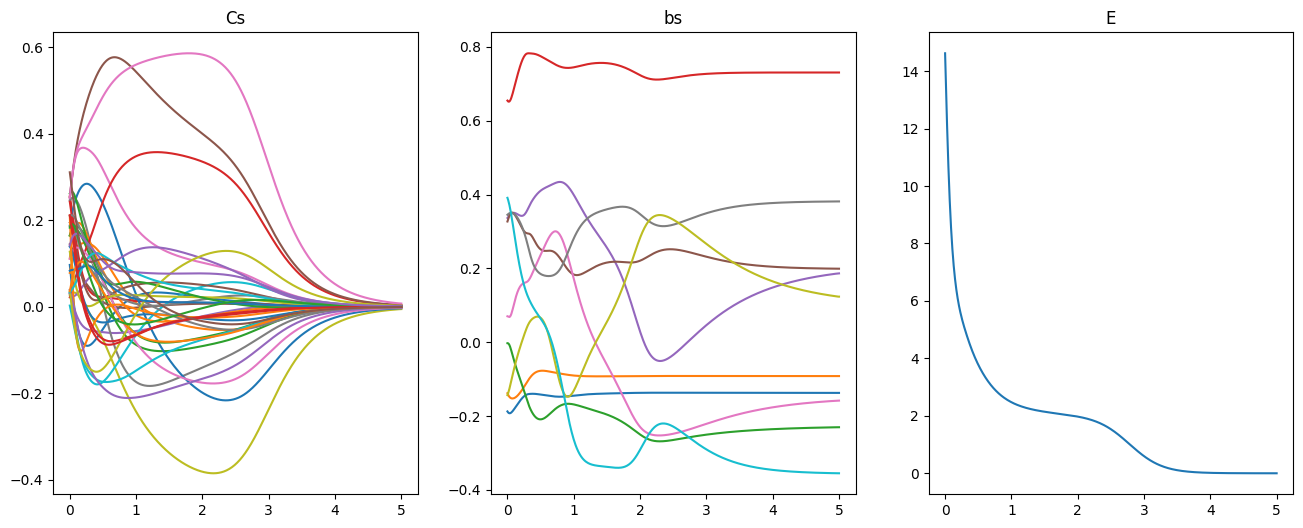

In [19]:
C_f, b_f = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
#C_f, b_f = y_to_Cb(y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)

#print(f"Final b =\n{b_f}")
#print(f"Final C =\n{C_f}")
#print(f"Energy: {Es[-1]}")
#print(f"Energy deviation =\n{Es[-1]-E_exact}")
print(f"Final energy: {Es[-1]}")

#print(f"Overlap matrix for final b:\n{b_f.T@b_f}")

print(f"Max b overlap coeff (ideally zero): {np.abs(np.max(b_f.T@b_f-np.eye(num_mctdhf_orbitals)))}")

b_arr = np.array(bs)
Es = np.array(Es)
Cs = np.array(Cs)
#t = np.linspace(0, dt*num_steps, len(Cs))
t = np.linspace(0, solver.t, len(Es))

fig, axs = plt.subplots(1, 3, figsize=(16,6))
axs[0].plot(t, np.real(Cs))
axs[0].set_title('Cs')
axs[1].plot(t, np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,0]))
axs[1].set_title('bs')
#ax[2].plot(t, E_exact*np.ones_like(Es), 'k--')
axs[2].plot(t, np.real(Es))
axs[2].set_title('E')

# for ax in axs:
#     ax.set_xlim(right=t_final)

plt.show()

In [ ]:
C = C_f.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets)
print(C.T+C)
#contract('ijpq, ia, ja -> pq', dCI.E_pq_alpha, C.conj(), C)
#contract('ijpq, ai, aj -> pq', dCI.E_pq_beta, C.conj(), C)
#np.nonzero(contract('ijpqrs, ia, ja', dCI.E_pqrs_alpha, C.conj(), C))  # Both spin alpha
#np.nonzero(contract('ijpqrs, ai, aj', dCI.E_pqrs_beta, C.conj(), C))  # Both spin beta
#contract('ik, ijpq, klrs, jl -> pqrs', C.conj(), dCI.E_pq_alpha, dCI.E_pq_beta, C)  # Mixed spin term
#contract('ki, ijpq, klrs, lj -> pqrs', C.conj(), dCI.E_pq_beta, dCI.E_pq_alpha, C) # Mixed spin term

[[ 0.15902332+0.j  0.10686836+0.j  0.28671922+0.j -0.34173265+0.j
   0.19046655+0.j  0.32477343+0.j]
 [ 0.10686836+0.j -0.03718166+0.j  0.30788405+0.j -0.24831291+0.j
   0.12879099+0.j  0.21043658+0.j]
 [ 0.28671922+0.j  0.30788405+0.j  0.01926547+0.j -0.26481834+0.j
   0.25659677+0.j  0.37754735+0.j]
 [-0.34173265+0.j -0.24831291+0.j -0.26481834+0.j  0.27951487+0.j
  -0.42796642+0.j -0.56730872+0.j]
 [ 0.19046655+0.j  0.12879099+0.j  0.25659677+0.j -0.42796642+0.j
  -0.19114907+0.j -0.00690509+0.j]
 [ 0.32477343+0.j  0.21043658+0.j  0.37754735+0.j -0.56730872+0.j
  -0.00690509+0.j  0.04208108+0.j]]


In [ ]:
D = dCI.get_1p_RDM(C_f.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets))

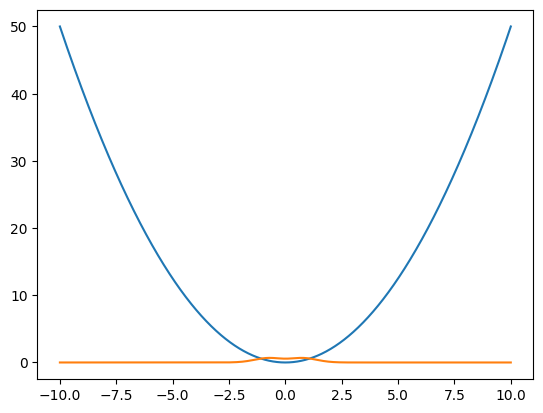

In [ ]:
plt.plot(x, pot(x))
plt.plot(x, np.real(np.diag(spf.T@(b_f@D@b_f.T)@spf)))
plt.show()

In [ ]:
class MCDTHF:
    def __init__(self, h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons):
        self.h = h
        self.g = g
        self.num_mctdhf_orbitals = num_mctdhf_orbitals
        self.num_spatial_orbitals = num_spatial_orbitals

        num_alpha_dets = int(comb(num_mctdhf_orbitals, num_alpha_electrons))
        num_beta_dets = int(comb(num_mctdhf_orbitals, num_beta_electrons))
        self.num_slater_dets = num_alpha_dets*num_beta_dets
        self.C_shape = (num_alpha_dets, num_beta_dets)

        self.dCI = SemiDirectCI(self.num_mctdhf_orbitals, 
                                num_alpha_electrons, 
                                num_beta_electrons)
        
    
    def __call__(self, t, y):
        
        C, b = y_to_Cb(y, self.num_mctdhf_orbitals, self.num_spatial_orbitals, self.num_slater_dets)
        bc = b.conj()

        h_1 = contract('jm, ij -> im', b, self.h)
        h_2 = contract('in, im -> nm', bc, h_1)
        h_3 = contract('in, nm -> im', b, h_2)

        g_2 = contract('jq, ls, ijkl -> iqks', bc, b, self.g)
        g_3 = contract('kr, iqks -> iqrs', b, g_2)
        g_4 = contract('ip, iqrs -> pqrs', bc, g_3)
        g_5 = contract('ip, pqrs -> iqrs', b, g_4)

        
        #D, d = self.dCI.get_RDMs_equal_spins(C.reshape(self.C_shape))
        D, d = self.dCI.get_RDMs(C.reshape(self.C_shape))
        #eps = 1e-10
        #D_reg = D + eps*expm(-D/eps)
        D_inv = np.linalg.pinv(D)#_reg)
        #D_inv = pinv(D_reg)

        b_dot = -1j*(h_1 - h_3 + contract('np, pqrs, iqrs -> in', D_inv, d, g_3-g_5))

        sigma = self.dCI.get_sigma(C.reshape(self.C_shape), h_2, g_4).flatten()
        
        ## "Renormalization" from (127) in Beck et al. rewritten to direct CI
        #E = self.dCI.calculate_energy_from_RDMs(D,d)
        #C_dot = -(sigma-E*C) 

        C_dot = -1j*sigma

        return Cb_to_y(C_dot, b_dot)

In [ ]:
mctdhf_fun = MCDTHF(h, g, num_mctdhf_orbitals, num_spatial_orbitals, num_alpha_electrons, num_beta_electrons)

y_init = Cb_to_y(C_f, b_f)

Cs_rt = [C_f]
bs_rt = [b_f]

Es_rt = [Es[-1]]

t_init = 0
t_final = 3.0
solver = DOP853(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK45(mctdhf_fun, t_init, y_init, t_final, max_step = 1e-2)
#solver = RK23(mctdhf_fun, t_init, y_init, t_final, max_step = 0.001)

while solver.status == 'running':
    msg = solver.step()

    C, b = y_to_Cb(solver.y, num_mctdhf_orbitals, num_spatial_orbitals, num_mctdhf_dets)
    C = np.divide(C, np.sqrt(C.T.conj()@C))

    b = np.divide(b, np.sqrt(np.einsum('ij, ij -> j', b.conj(), b)))
    b = gram_schmidt(b)
    bc = b.conj()
 
    h_1 = contract('jm, ij -> im', b, h)
    h_2 = contract('in, im -> nm', bc, h_1)

    g_2 = contract('jq, ls, ijkl -> iqks', bc, b, g)
    g_3 = contract('kr, iqks -> iqrs', b, g_2)
    g_4 = contract('ip, iqrs -> pqrs', bc, g_3)

    E = dCI.calculate_energy(C.reshape(num_mctdhf_alpha_dets, num_mctdhf_beta_dets), h_2, g_4)

    Es_rt.append(np.real(E))
    Cs_rt.append(C)
    bs_rt.append(b)

    solver.y = Cb_to_y(C, b)
else:
    if solver.status != 'finished':
        raise(RuntimeError(msg))

/home/ol/projects/mctdhf/venv/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ol/projects/mctdhf/venv/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


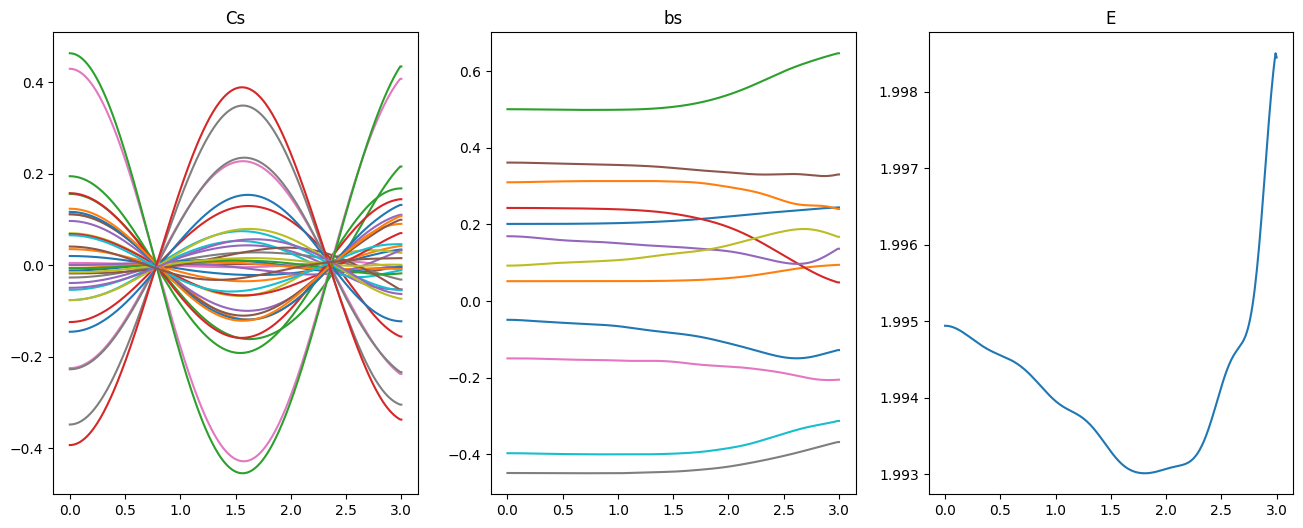

In [ ]:
Es_rt = np.array(Es_rt)
Cs_rt = np.array(Cs_rt)
b_arr = np.array(bs_rt)

t = np.linspace(t_init, solver.t, len(Cs_rt))

fig, ax = plt.subplots(1, 3, figsize=(16,6))
ax[0].plot(t, np.real(Cs_rt))
ax[0].set_title('Cs')
ax[1].plot(t, np.real(b_arr.reshape(b_arr.shape[0],*b_init.shape)[:,:,0]))
ax[1].set_title('bs')
#ax[2].plot(t, E_exact*np.ones_like(Es_rt), 'k--')
ax[2].plot(t, Es_rt)
ax[2].set_title('E')
plt.show()